# PFAS Auxiliary QSAR Results Summary

Summarize `benchmark_results/pfas_aux_qsar_full` from `run_autoqsar_ga_benchmarks.py --pfas-aux-workbook`, rebuilding the displayed tables from per-dataset outputs when resumed runs leave top-level combined CSVs stale.


In [46]:
from pathlib import Path
import json
import math
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
try:
    from IPython.display import display
except Exception:
    def display(value):
        print(value)

ROOT = Path.cwd()
if ROOT.name == 'portable_colab_qsar_bundle':
    ROOT = ROOT.parent

# Set RUN_DIR explicitly to compare a specific run, or leave as None to use the latest unified PFAS workbook run.
RUN_DIR = None
PREFERRED_RUN_DIR = ROOT / 'benchmark_results' / 'pfas_aux_qsar_full'


def _read_json(path):
    try:
        return json.loads(path.read_text(encoding='utf-8'))
    except Exception:
        return {}


def _file_mtime(path):
    try:
        return path.stat().st_mtime
    except OSError:
        return 0.0


def _run_sort_key(run_dir):
    files = [run_dir / name for name in [
        'run_complete.json', 'run_config.json', 'summary_metrics.csv', 'predictions.csv',
        'tabpfn_daily_budget_estimate.csv', 'step_runtime_summary.csv'
    ]]
    child_files = list(run_dir.glob('*/metrics.csv')) + list(run_dir.glob('*/predictions.csv'))
    return max([_file_mtime(run_dir), *[_file_mtime(path) for path in files + child_files]])


def _is_unified_pfas_aux_run(run_dir):
    has_top_level = (run_dir / 'summary_metrics.csv').exists() and (run_dir / 'predictions.csv').exists()
    has_child_outputs = any(run_dir.glob('*/metrics.csv')) and any(run_dir.glob('*/predictions.csv'))
    if not has_top_level and not has_child_outputs:
        return False
    config = _read_json(run_dir / 'run_config.json')
    if str(config.get('pfas_aux_workbook', '')).strip():
        return True
    preview_path = run_dir / 'summary_metrics.csv'
    if not preview_path.exists():
        child_metrics = sorted(run_dir.glob('*/metrics.csv'))
        preview_path = child_metrics[0] if child_metrics else preview_path
    try:
        preview = pd.read_csv(preview_path, nrows=25)
    except Exception:
        return False
    if 'benchmark_suite' in preview.columns and preview['benchmark_suite'].astype(str).str.eq('pfas_aux_workbook').any():
        return True
    return {'sheet', 'target', 'smiles_subset'}.issubset(set(preview.columns))


def find_latest_pfas_aux_run(root):
    if PREFERRED_RUN_DIR.exists() and _is_unified_pfas_aux_run(PREFERRED_RUN_DIR):
        return PREFERRED_RUN_DIR
    benchmark_root = root / 'benchmark_results'
    candidates = [path for path in benchmark_root.glob('pfas_aux_qsar*') if path.is_dir() and _is_unified_pfas_aux_run(path)]
    if not candidates:
        raise FileNotFoundError('No compatible PFAS auxiliary benchmark run found under benchmark_results/. Expected a run from run_autoqsar_ga_benchmarks.py --pfas-aux-workbook with summary_metrics.csv/predictions.csv or per-dataset outputs.')
    return sorted(candidates, key=_run_sort_key)[-1]


if RUN_DIR is None:
    RUN_DIR = find_latest_pfas_aux_run(ROOT)
else:
    RUN_DIR = Path(RUN_DIR)
    if not RUN_DIR.is_absolute():
        RUN_DIR = ROOT / RUN_DIR

summary_path = RUN_DIR / 'summary_metrics.csv'
predictions_path = RUN_DIR / 'predictions.csv'
config_path = RUN_DIR / 'run_config.json'
complete_path = RUN_DIR / 'run_complete.json'
run_config = _read_json(config_path) if config_path.exists() else {}
run_complete = _read_json(complete_path) if complete_path.exists() else {}


def _read_csv_if_exists(path):
    return pd.read_csv(path) if path.exists() else pd.DataFrame()


def load_top_level_outputs(run_dir):
    return _read_csv_if_exists(run_dir / 'summary_metrics.csv'), _read_csv_if_exists(run_dir / 'predictions.csv')


def load_per_dataset_outputs(run_dir):
    metric_tables = []
    prediction_tables = []
    for dataset_dir in sorted(path for path in run_dir.iterdir() if path.is_dir()):
        metrics_path = dataset_dir / 'metrics.csv'
        predictions_path = dataset_dir / 'predictions.csv'
        if metrics_path.exists():
            table = pd.read_csv(metrics_path)
            if 'dataset' not in table.columns:
                table['dataset'] = dataset_dir.name
            table['source_dataset_dir'] = dataset_dir.name
            metric_tables.append(table)
        if predictions_path.exists():
            table = pd.read_csv(predictions_path)
            if 'dataset' not in table.columns:
                table['dataset'] = dataset_dir.name
            table['source_dataset_dir'] = dataset_dir.name
            prediction_tables.append(table)
    metrics_df = pd.concat(metric_tables, ignore_index=True, sort=False) if metric_tables else pd.DataFrame()
    predictions_df = pd.concat(prediction_tables, ignore_index=True, sort=False) if prediction_tables else pd.DataFrame()
    return metrics_df, predictions_df


top_metrics, top_predictions = load_top_level_outputs(RUN_DIR)
child_metrics, child_predictions = load_per_dataset_outputs(RUN_DIR)
child_latest = max([0.0, *[_file_mtime(path) for path in RUN_DIR.glob('*/metrics.csv')], *[_file_mtime(path) for path in RUN_DIR.glob('*/predictions.csv')]])
top_latest = max(_file_mtime(summary_path), _file_mtime(predictions_path))
use_child_outputs = (
    not child_metrics.empty
    and not child_predictions.empty
    and (
        top_metrics.empty
        or top_predictions.empty
        or child_metrics['dataset'].nunique() > top_metrics.get('dataset', pd.Series(dtype=object)).nunique()
        or child_latest > top_latest
    )
)
if use_child_outputs:
    metrics = child_metrics.copy()
    predictions = child_predictions.copy()
    output_source = 'per-dataset metrics.csv/predictions.csv files'
else:
    if top_metrics.empty:
        raise FileNotFoundError(summary_path)
    if top_predictions.empty:
        raise FileNotFoundError(predictions_path)
    metrics = top_metrics.copy()
    predictions = top_predictions.copy()
    output_source = 'top-level summary_metrics.csv/predictions.csv'


def add_dataset_labels(df):
    df = df.copy()
    if 'dataset' not in df.columns:
        df['dataset'] = ''
    if 'dataset_label' in df.columns:
        df['dataset_label'] = df['dataset_label'].fillna(df.get('sheet', df['dataset'])).fillna(df['dataset']).astype(str)
    elif 'sheet' in df.columns:
        df['dataset_label'] = df['sheet'].fillna(df['dataset']).astype(str)
    else:
        df['dataset_label'] = df['dataset'].astype(str)
    if 'sheet' in df.columns:
        sheet_values = df['sheet'].fillna('').astype(str).str.strip()
        df.loc[sheet_values.ne(''), 'dataset_label'] = sheet_values.loc[sheet_values.ne('')]
    parts = df['dataset_label'].str.extract(r'^(?P<target_from_label>.+?)_(?P<smiles_subset_from_label>(?:pfas|nonpfas).*)$')
    if 'target' not in df.columns:
        df['target'] = parts['target_from_label'].fillna(df['dataset_label'])
    else:
        df['target'] = df['target'].fillna(parts['target_from_label']).fillna(df['dataset_label'])
    if 'smiles_subset' not in df.columns:
        df['smiles_subset'] = parts['smiles_subset_from_label'].fillna('')
    else:
        df['smiles_subset'] = df['smiles_subset'].fillna(parts['smiles_subset_from_label']).fillna('')
    return df


metrics = add_dataset_labels(metrics)
# Harmonize labels across mixed cached rows for the same dataset. Prefer explicit workbook sheet labels.
label_lookup = {}
if 'dataset' in metrics.columns:
    for dataset_id, group in metrics.groupby('dataset', dropna=False):
        chosen = ''
        if 'sheet' in group.columns:
            sheet_values = group['sheet'].dropna().astype(str).str.strip()
            sheet_values = sheet_values[sheet_values.ne('')]
            if not sheet_values.empty:
                chosen = sheet_values.iloc[0]
        if not chosen:
            label_values = group['dataset_label'].dropna().astype(str).str.strip()
            label_values = label_values[label_values.ne('')]
            if not label_values.empty:
                chosen = label_values.iloc[0]
        if chosen:
            label_lookup[dataset_id] = chosen
    metrics['dataset_label'] = metrics['dataset'].map(label_lookup).fillna(metrics['dataset_label'])
if 'dataset' not in predictions.columns and 'dataset_label' in predictions.columns:
    predictions['dataset'] = predictions['dataset_label']
if 'dataset' not in predictions.columns:
    predictions['dataset'] = ''
if 'dataset_label' not in predictions.columns:
    predictions = predictions.merge(metrics[['dataset', 'dataset_label']].drop_duplicates(), on='dataset', how='left')
predictions['dataset_label'] = predictions['dataset_label'].fillna(predictions['dataset'])
if label_lookup:
    predictions['dataset_label'] = predictions['dataset'].map(label_lookup).fillna(predictions['dataset_label'])
if 'observed' not in predictions.columns:
    predictions['observed'] = np.nan
if 'predicted' not in predictions.columns:
    predictions['predicted'] = np.nan
if 'y_true' in predictions.columns:
    predictions['observed'] = pd.to_numeric(predictions['observed'], errors='coerce').fillna(pd.to_numeric(predictions['y_true'], errors='coerce'))
else:
    predictions['observed'] = pd.to_numeric(predictions['observed'], errors='coerce')
if 'y_pred' in predictions.columns:
    predictions['predicted'] = pd.to_numeric(predictions['predicted'], errors='coerce').fillna(pd.to_numeric(predictions['y_pred'], errors='coerce'))
else:
    predictions['predicted'] = pd.to_numeric(predictions['predicted'], errors='coerce')
if 'smiles' not in predictions.columns:
    predictions['smiles'] = np.nan
if 'QSAR_READY_SMILES' in predictions.columns:
    predictions['smiles'] = predictions['smiles'].fillna(predictions['QSAR_READY_SMILES'])
for required_column in ['dataset', 'model', 'split', 'observed', 'predicted']:
    if required_column not in predictions.columns:
        raise ValueError(f'predictions.csv is missing required column after normalization: {required_column}')

stale_top_level_outputs = (
    bool(config_path.exists())
    and bool(summary_path.exists())
    and bool(predictions_path.exists())
    and max(_file_mtime(summary_path), _file_mtime(predictions_path)) < max(_file_mtime(config_path), child_latest)
)
run_info = pd.DataFrame([
    {
        'run_dir': str(RUN_DIR),
        'selected_by': 'benchmark_results/pfas_aux_qsar_full' if RUN_DIR == PREFERRED_RUN_DIR else 'latest compatible PFAS auxiliary run',
        'display_source': output_source,
        'pfas_aux_workbook': run_config.get('pfas_aux_workbook', ''),
        'benchmark_profile': run_config.get('benchmark_profile', ''),
        'target_transform': run_config.get('target_transform', ''),
        'split_strategy': run_config.get('split_strategy', ''),
        'run_complete': complete_path.exists(),
        'summary_rows': len(metrics),
        'prediction_rows': len(predictions),
        'dataset_count': metrics['dataset'].nunique() if 'dataset' in metrics.columns else metrics['dataset_label'].nunique(),
        'model_count': metrics['model'].nunique() if 'model' in metrics.columns else np.nan,
        'top_level_outputs_stale': stale_top_level_outputs,
    }
])

print(f'Run directory: {RUN_DIR}')
print(f'Display source: {output_source}')
print(f'Metric rows: {len(metrics):,} | Prediction rows: {len(predictions):,}')
if stale_top_level_outputs and use_child_outputs:
    warnings.warn('Top-level summary_metrics.csv/predictions.csv appear older or narrower than per-dataset outputs; notebook is displaying combined per-dataset files instead.', RuntimeWarning)
elif stale_top_level_outputs:
    warnings.warn('summary_metrics.csv/predictions.csv appear older than run_config.json or per-dataset outputs.', RuntimeWarning)
run_info




Run directory: C:\Users\Scott.Coffin\OneDrive - California OEHHA\R_new\AutoQSAR\benchmark_results\pfas_aux_qsar_full
Display source: per-dataset metrics.csv/predictions.csv files
Metric rows: 109 | Prediction rows: 20,408


<positron-console-cell-46>:253: RuntimeWarning: Top-level summary_metrics.csv/predictions.csv appear older or narrower than per-dataset outputs; notebook is displaying combined per-dataset files instead.


,run_dir,selected_by,display_source,pfas_aux_workbook,benchmark_profile,target_transform,split_strategy,run_complete,summary_rows,prediction_rows,dataset_count,model_count,top_level_outputs_stale
0,C:\Users\Scott.Coffin\OneDrive - California OE...,benchmark_results/pfas_aux_qsar_full,per-dataset metrics.csv/predictions.csv files,data\modeling_datasets_aux_features.xlsx,cost_optimized,raw,predefined,False,109,20408,5,30,True


## Model Performance

Rows are filtered to unified `run_autoqsar_ga_benchmarks.py` workflow families before ranking models. Older PFAS-specific cached rows such as `qsar_core_molecular_plus_auxiliary` are excluded.


In [47]:
allowed_workflows = {
    'conventional',
    'chemml deep learning',
    'chemprop v2',
    'maplight + gnn',
    'cfa',
    'ensemble',
}
metrics_for_display = metrics.copy()
if 'workflow' in metrics_for_display.columns:
    workflow_text = metrics_for_display['workflow'].fillna('').astype(str).str.strip().str.lower()
    metrics_for_display = metrics_for_display[workflow_text.isin(allowed_workflows)].copy()
if metrics_for_display.empty:
    raise ValueError('No rows from run_autoqsar_ga_benchmarks.py workflow families were found after filtering. Check that the selected run directory contains unified benchmark outputs.')

if 'error' in metrics_for_display.columns:
    error_text = metrics_for_display['error'].fillna('').astype(str).str.strip()
    ok = metrics_for_display[error_text.eq('')].copy()
else:
    ok = metrics_for_display.copy()
if 'status' in ok.columns:
    status_text = ok['status'].fillna('').astype(str).str.strip().str.lower()
    ok = ok[status_text.eq('') | status_text.isin(['completed', 'success', 'ok'])].copy()
for numeric_col in ['test_rmse', 'test_mae', 'test_r2', 'cv_rmse', 'cv_r2', 'n_train', 'n_test']:
    if numeric_col in ok.columns:
        ok[numeric_col] = pd.to_numeric(ok[numeric_col], errors='coerce')
if 'test_rmse' in ok.columns:
    ok = ok[ok['test_rmse'].notna()].copy()
if ok.empty:
    raise ValueError('No completed model rows with test metrics found in selected PFAS auxiliary outputs.')

status_summary = pd.DataFrame({
    'all_metric_rows': [len(metrics)],
    'unified_workflow_rows': [len(metrics_for_display)],
    'displayed_completed_rows': [len(ok)],
    'datasets': [ok['dataset_label'].nunique()],
    'models': [ok['model'].nunique() if 'model' in ok.columns else np.nan],
    'excluded_non_unified_rows': [len(metrics) - len(metrics_for_display)],
})
display(status_summary)

display_cols = [
    'dataset_label', 'target', 'smiles_subset', 'model', 'workflow',
    'n_train', 'n_test', 'cv_rmse', 'cv_r2', 'test_rmse', 'test_mae', 'test_r2', 'test_spearman',
    'primary_metric', 'primary_metric_value', 'auxiliary_feature_count', 'shared_feature_matrix_cache_hit', 'cache_status', 'elapsed_seconds', 'source_dataset_dir'
]
available_cols = [c for c in display_cols if c in ok.columns]
performance_table = (
    ok[available_cols]
    .sort_values(['dataset_label', 'test_rmse', 'test_mae'], ascending=[True, True, True])
    .reset_index(drop=True)
)
performance_table



,all_metric_rows,unified_workflow_rows,displayed_completed_rows,datasets,models,excluded_non_unified_rows
0,109,91,78,5,19,18


,dataset_label,target,smiles_subset,model,workflow,n_train,n_test,cv_rmse,cv_r2,test_rmse,test_mae,test_r2,test_spearman,primary_metric,primary_metric_value,auxiliary_feature_count,shared_feature_matrix_cache_hit,cache_status,elapsed_seconds,source_dataset_dir
0,HLe_invivo_pfas_tsca,hle_invivo,pfas_tsca,HistGradientBoosting,conventional,164,41,0.565735,0.831660,0.634530,0.540503,0.845184,0.905411,rmse,0.634530,19.0,False,NaN,57.480,hle_invivo_pfas_tsca
1,HLe_invivo_pfas_tsca,hle_invivo,pfas_tsca,CFA (Combinatorial Fusion),cfa,164,41,NaN,NaN,0.646433,0.532461,0.839321,0.902893,rmse,0.646433,19.0,False,NaN,541.974,hle_invivo_pfas_tsca
2,HLe_invivo_pfas_tsca,hle_invivo,pfas_tsca,ElasticNetCV,conventional,164,41,0.584739,0.816132,0.659471,0.549913,0.832774,0.895835,rmse,0.659471,19.0,False,NaN,48.110,hle_invivo_pfas_tsca
3,HLe_invivo_pfas_tsca,hle_invivo,pfas_tsca,Ensemble (Weighted average (inverse train RMSE)),ensemble,164,41,NaN,NaN,0.692014,0.497407,0.804150,0.964286,rmse,0.692014,19.0,False,NaN,542.956,hle_invivo_pfas_tsca
4,HLe_invivo_pfas_tsca,hle_invivo,pfas_tsca,TabPFNRegressor,conventional,164,41,0.460577,0.886594,0.709183,0.588604,0.806612,0.758691,rmse,0.709183,19.0,False,NaN,176.778,hle_invivo_pfas_tsca
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
73,vdss_pfas_struct,vdss,pfas_struct,XGBoost,conventional,126,21,0.273533,0.813944,0.427591,0.330948,0.569623,0.785042,rmse,0.427591,19.0,False,NaN,105.189,vdss_pfas_struct
74,vdss_pfas_struct,vdss,pfas_struct,"Chemprop v2 (AttentiveFP, ensemble=1)",Chemprop v2,126,21,NaN,NaN,0.436082,0.310188,0.552360,0.760325,rmse,0.436082,19.0,False,NaN,292.858,vdss_pfas_struct
75,vdss_pfas_struct,vdss,pfas_struct,HistGradientBoosting,conventional,126,21,0.314100,0.745477,0.460963,0.372520,0.499821,0.813009,rmse,0.460963,19.0,False,NaN,71.093,vdss_pfas_struct
76,vdss_pfas_struct,vdss,pfas_struct,Tabular MLP,conventional,126,21,0.173101,0.921860,0.479538,0.351634,0.458699,0.843578,rmse,0.479538,19.0,False,NaN,82.255,vdss_pfas_struct


## Best Model Per Dataset

In [48]:
try:
    from scipy.stats import spearmanr
except Exception:
    spearmanr = None


def _target_family(label):
    text = str(label).lower()
    if text.startswith('hle') or 'hle_invivo' in text:
        return 'HLe_invivo'
    if text.startswith('vdss') or 'vdss' in text:
        return 'VDss'
    return str(label).split('_')[0]


def _subset_label(row):
    subset = str(row.get('smiles_subset', '') or '').strip()
    if subset:
        return subset
    label = str(row.get('dataset_label', row.get('dataset', ''))).strip()
    family = _target_family(label).lower()
    cleaned = label.lower().replace('hle_invivo_', '').replace('vdss_', '')
    return cleaned if cleaned and cleaned != family else label


def _adj_r2(r2, n, p):
    try:
        r2 = float(r2)
        n = int(n)
        p = int(p)
    except Exception:
        return np.nan
    if not np.isfinite(r2) or n <= 2 or p < 1:
        return np.nan
    # Avoid reporting impossible adjusted-R2 denominators for high-dimensional feature sets.
    p_eff = min(p, n - 2)
    denom = n - p_eff - 1
    if denom <= 0:
        return np.nan
    return 1.0 - (1.0 - r2) * ((n - 1.0) / denom)


def _spearman_stats(y_true, y_pred):
    y_true = pd.to_numeric(pd.Series(y_true), errors='coerce')
    y_pred = pd.to_numeric(pd.Series(y_pred), errors='coerce')
    mask = y_true.notna() & y_pred.notna()
    if int(mask.sum()) < 3 or spearmanr is None:
        return np.nan, np.nan
    try:
        rho, p_value = spearmanr(y_true.loc[mask], y_pred.loc[mask])
        return float(rho), float(p_value)
    except Exception:
        return np.nan, np.nan


def _rmse(y_true, y_pred):
    y_true = pd.to_numeric(pd.Series(y_true), errors='coerce')
    y_pred = pd.to_numeric(pd.Series(y_pred), errors='coerce')
    mask = y_true.notna() & y_pred.notna()
    if not mask.any():
        return np.nan
    return float(np.sqrt(np.mean((y_true.loc[mask].to_numpy() - y_pred.loc[mask].to_numpy()) ** 2)))


def _mae(y_true, y_pred):
    y_true = pd.to_numeric(pd.Series(y_true), errors='coerce')
    y_pred = pd.to_numeric(pd.Series(y_pred), errors='coerce')
    mask = y_true.notna() & y_pred.notna()
    if not mask.any():
        return np.nan
    return float(np.mean(np.abs(y_true.loc[mask].to_numpy() - y_pred.loc[mask].to_numpy())))


def _r2_score(y_true, y_pred):
    y_true = pd.to_numeric(pd.Series(y_true), errors='coerce')
    y_pred = pd.to_numeric(pd.Series(y_pred), errors='coerce')
    mask = y_true.notna() & y_pred.notna()
    if int(mask.sum()) < 2:
        return np.nan
    yt = y_true.loc[mask].to_numpy(dtype=float)
    yp = y_pred.loc[mask].to_numpy(dtype=float)
    denom = float(np.sum((yt - yt.mean()) ** 2))
    if denom <= 0:
        return np.nan
    return float(1.0 - np.sum((yt - yp) ** 2) / denom)


def _best_model_predictions(row, split_name):
    mask = (
        predictions['dataset'].eq(row['dataset'])
        & predictions['model'].eq(row['model'])
        & predictions['split'].astype(str).str.lower().eq(split_name)
    )
    sub = predictions.loc[mask].copy()
    sub['observed'] = pd.to_numeric(sub['observed'], errors='coerce')
    sub['predicted'] = pd.to_numeric(sub['predicted'], errors='coerce')
    return sub.dropna(subset=['observed', 'predicted'])


def _cv_predictions(row):
    mask = (
        predictions['dataset'].eq(row['dataset'])
        & predictions['model'].eq(row['model'])
        & predictions['split'].astype(str).str.lower().eq('train')
    )
    sub = predictions.loc[mask].copy()
    if 'cv_oof_pred' not in sub.columns:
        return pd.DataFrame()
    sub['observed'] = pd.to_numeric(sub['observed'], errors='coerce')
    sub['cv_oof_pred'] = pd.to_numeric(sub['cv_oof_pred'], errors='coerce')
    return sub.dropna(subset=['observed', 'cv_oof_pred'])


def _metric_from_row(row, name):
    return pd.to_numeric(pd.Series([row.get(name, np.nan)]), errors='coerce').iloc[0]


for metric_col in ['test_rmse', 'test_mae', 'test_r2', 'cv_rmse', 'cv_mae', 'cv_r2', 'train_rmse', 'train_mae', 'train_r2']:
    if metric_col in ok.columns:
        ok[metric_col] = pd.to_numeric(ok[metric_col], errors='coerce')

best_models = (
    ok.sort_values(['dataset', 'test_rmse', 'test_mae'], ascending=[True, True, True])
    .groupby('dataset', as_index=False)
    .first()
)

best_metric_rows = []
plot_parts = []
for _, row in best_models.iterrows():
    p_features = _metric_from_row(row, 'selected_feature_count')
    if not np.isfinite(p_features):
        p_features = _metric_from_row(row, 'feature_count_with_auxiliary')
    if not np.isfinite(p_features):
        p_features = _metric_from_row(row, 'post_dedup_feature_count')
    if not np.isfinite(p_features):
        p_features = np.nan

    train_pred = _best_model_predictions(row, 'train')
    test_pred = _best_model_predictions(row, 'test')
    cv_pred = _cv_predictions(row)

    train_rho, train_p = _spearman_stats(train_pred['observed'], train_pred['predicted']) if not train_pred.empty else (np.nan, np.nan)
    test_rho, test_p = _spearman_stats(test_pred['observed'], test_pred['predicted']) if not test_pred.empty else (np.nan, np.nan)
    cv_rho, cv_p = _spearman_stats(cv_pred['observed'], cv_pred['cv_oof_pred']) if not cv_pred.empty else (np.nan, np.nan)

    n_train = int(len(train_pred)) if len(train_pred) else int(row.get('n_train', 0) or 0)
    n_test = int(len(test_pred)) if len(test_pred) else int(row.get('n_test', 0) or 0)
    p_for_adj = int(p_features) if np.isfinite(p_features) else 1

    train_r2 = _r2_score(train_pred['observed'], train_pred['predicted']) if not train_pred.empty else _metric_from_row(row, 'train_r2')
    test_r2 = _r2_score(test_pred['observed'], test_pred['predicted']) if not test_pred.empty else _metric_from_row(row, 'test_r2')
    cv_r2 = _r2_score(cv_pred['observed'], cv_pred['cv_oof_pred']) if not cv_pred.empty else _metric_from_row(row, 'cv_r2')

    best_metric_rows.append({
        'dataset': row.get('dataset', ''),
        'dataset_label': row.get('dataset_label', ''),
        'target_family': _target_family(row.get('dataset_label', row.get('dataset', ''))),
        'smiles_subset': row.get('smiles_subset', '') or _subset_label(row),
        'facet_row': _subset_label(row),
        'model': row.get('model', ''),
        'workflow': row.get('workflow', ''),
        'n_train': n_train,
        'n_test': n_test,
        'adj_r2_feature_count': p_for_adj if np.isfinite(p_features) else np.nan,
        'cv_r2': cv_r2,
        'cv_adj_r2': _adj_r2(cv_r2, n_train, p_for_adj),
        'cv_rmse': _rmse(cv_pred['observed'], cv_pred['cv_oof_pred']) if not cv_pred.empty else _metric_from_row(row, 'cv_rmse'),
        'cv_mae': _mae(cv_pred['observed'], cv_pred['cv_oof_pred']) if not cv_pred.empty else _metric_from_row(row, 'cv_mae'),
        'cv_spearman': cv_rho if np.isfinite(cv_rho) else _metric_from_row(row, 'cv_spearman'),
        'cv_spearman_p': cv_p,
        'train_r2': train_r2,
        'train_adj_r2': _adj_r2(train_r2, n_train, p_for_adj),
        'train_rmse': _rmse(train_pred['observed'], train_pred['predicted']) if not train_pred.empty else _metric_from_row(row, 'train_rmse'),
        'train_mae': _mae(train_pred['observed'], train_pred['predicted']) if not train_pred.empty else _metric_from_row(row, 'train_mae'),
        'train_spearman': train_rho if np.isfinite(train_rho) else _metric_from_row(row, 'train_spearman'),
        'train_spearman_p': train_p,
        'test_r2': test_r2,
        'test_adj_r2': _adj_r2(test_r2, n_test, p_for_adj),
        'test_rmse': _rmse(test_pred['observed'], test_pred['predicted']) if not test_pred.empty else _metric_from_row(row, 'test_rmse'),
        'test_mae': _mae(test_pred['observed'], test_pred['predicted']) if not test_pred.empty else _metric_from_row(row, 'test_mae'),
        'test_spearman': test_rho if np.isfinite(test_rho) else _metric_from_row(row, 'test_spearman'),
        'test_spearman_p': test_p,
    })

    for split_name, sub in [('Train', train_pred), ('Test', test_pred)]:
        if sub.empty:
            continue
        sub = sub.copy()
        sub['plot_split'] = split_name
        sub['dataset_label'] = row.get('dataset_label', row.get('dataset', ''))
        sub['target_family'] = _target_family(row.get('dataset_label', row.get('dataset', '')))
        sub['facet_row'] = _subset_label(row)
        sub['model'] = row.get('model', '')
        plot_parts.append(sub)

best_model_performance = pd.DataFrame(best_metric_rows)
if best_model_performance.empty:
    raise ValueError('No best model performance rows could be computed.')

best_model_performance = best_model_performance.sort_values(
    ['facet_row', 'target_family'],
    key=lambda values: values.map(lambda x: {'HLe_invivo': 0, 'VDss': 1}.get(str(x), str(x))) if values.name == 'target_family' else values,
).reset_index(drop=True)

best_cols = [
    'dataset_label', 'target_family', 'smiles_subset', 'model', 'workflow', 'n_train', 'n_test',
    'cv_r2', 'cv_adj_r2', 'cv_rmse', 'cv_mae', 'cv_spearman', 'cv_spearman_p',
    'train_r2', 'train_adj_r2', 'train_rmse', 'train_mae', 'train_spearman', 'train_spearman_p',
    'test_r2', 'test_adj_r2', 'test_rmse', 'test_mae', 'test_spearman', 'test_spearman_p'
]
best_model_performance[[c for c in best_cols if c in best_model_performance.columns]]


,dataset_label,target_family,smiles_subset,model,workflow,n_train,n_test,cv_r2,cv_adj_r2,cv_rmse,...,train_rmse,train_mae,train_spearman,train_spearman_p,test_r2,test_adj_r2,test_rmse,test_mae,test_spearman,test_spearman_p
0,vdss_nonpfas_struct,VDss,nonpfas_struct,SVR,conventional,1441,347,0.742679,0.627221,0.329542,...,0.150949,0.096783,0.981545,0.000000e+00,0.434360,-194.711596,0.488167,0.382875,0.606420,3.174258e-36
1,hle_invivo_pfas_struct,HLe_invivo,pfas_struct,Random forest,conventional,307,88,0.875958,0.738230,0.436506,...,0.154418,0.104149,0.990546,3.433453e-265,0.708356,-24.373016,0.599007,0.470415,0.752518,2.838173e-17
2,vdss_pfas_struct,VDss,pfas_struct,CFA (Combinatorial Fusion),cfa,126,21,0.917663,0.771285,0.172545,...,0.059325,0.035804,0.992020,2.171379e-113,0.700259,-4.994828,0.356843,0.283920,0.903416,2.035117e-08
3,HLe_invivo_pfas_tsca,HLe_invivo,pfas_tsca,HistGradientBoosting,conventional,164,41,0.831660,0.767463,0.565735,...,0.350290,0.261444,0.958004,8.542597e-90,0.845184,-5.192644,0.634530,0.540503,0.905411,4.296594e-16
4,VDss_pfas_tsca,VDss,pfas_tsca,Tabular CNN,conventional,62,26,-7.551520,-9.432855,0.682096,...,0.115361,0.089015,0.906814,3.481998e-24,-0.102124,-0.968078,0.355504,0.273255,-0.167724,4.127898e-01


## Best-Model Actual vs Predicted Scatterplots

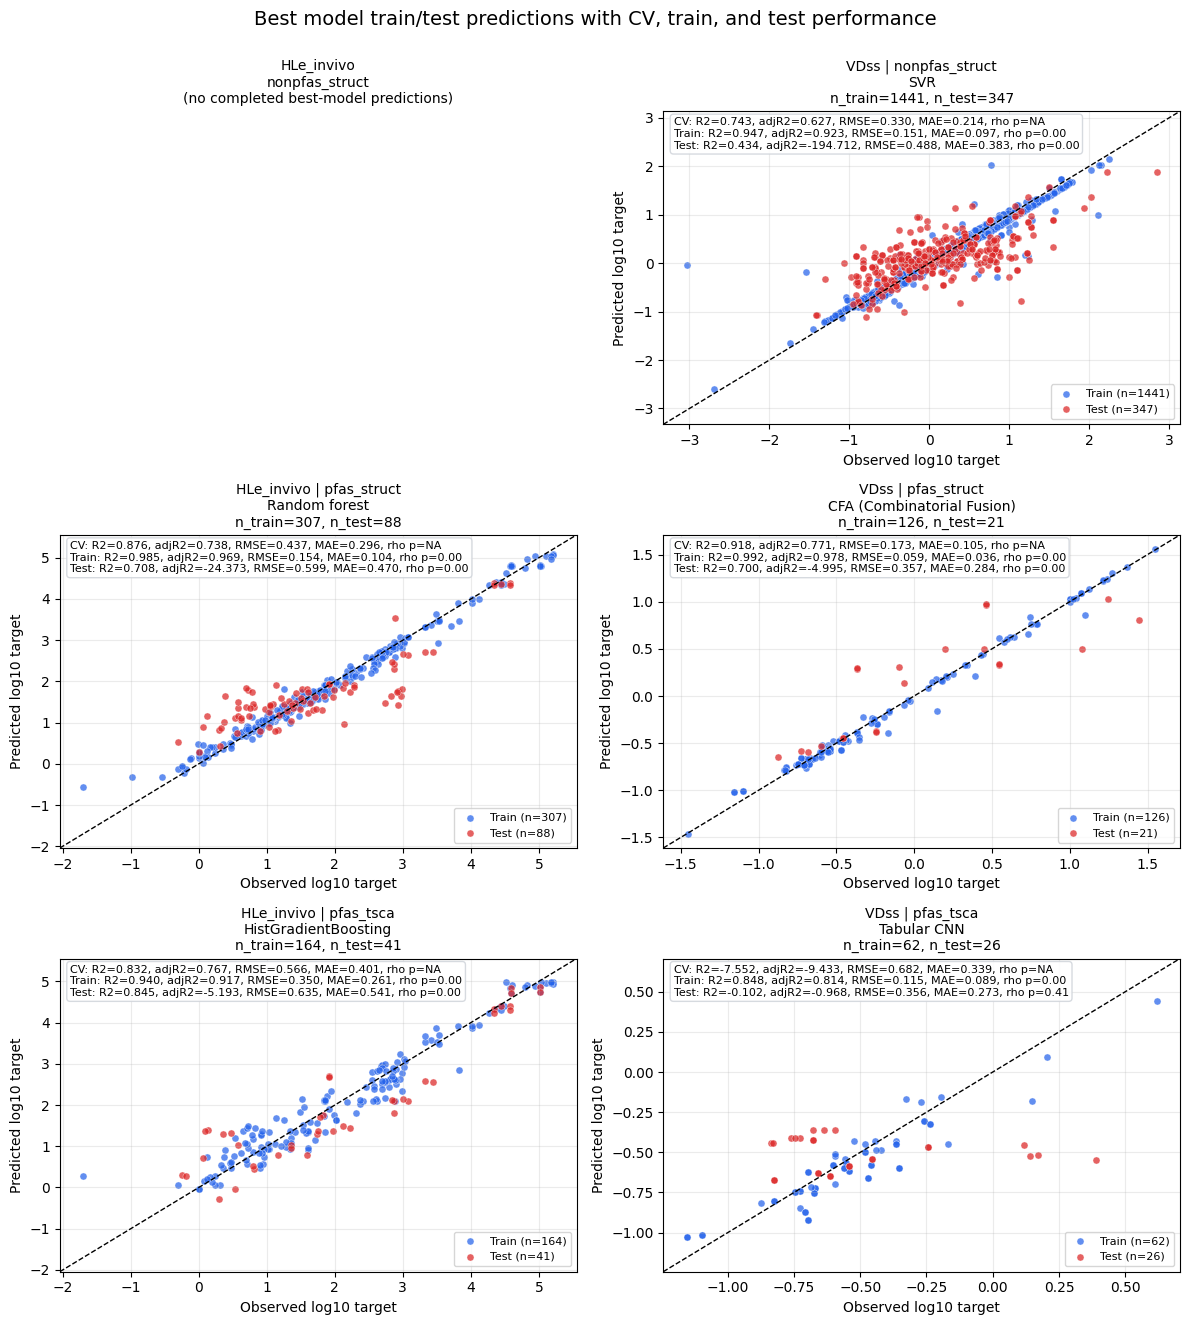

In [49]:
plot_df = pd.concat(plot_parts, ignore_index=True) if plot_parts else pd.DataFrame()
if plot_df.empty:
    raise ValueError('No train/test prediction rows found for best models.')
plot_df['observed'] = pd.to_numeric(plot_df['observed'], errors='coerce')
plot_df['predicted'] = pd.to_numeric(plot_df['predicted'], errors='coerce')
plot_df = plot_df.dropna(subset=['observed', 'predicted', 'dataset_label', 'target_family', 'facet_row'])
if plot_df.empty:
    raise ValueError('Best-model prediction rows were found, but none had numeric observed/predicted values.')

perf_lookup = best_model_performance.set_index(['target_family', 'facet_row']).to_dict(orient='index')
row_order = sorted(best_model_performance['facet_row'].dropna().unique().tolist())
col_order = ['HLe_invivo', 'VDss']
nrows = max(1, len(row_order))
fig, axes = plt.subplots(nrows, 2, figsize=(12.0, 4.4 * nrows), squeeze=False, sharex=False, sharey=False)
colors = {'Train': '#2563eb', 'Test': '#dc2626'}

def _fmt(value, digits=3):
    try:
        value = float(value)
    except Exception:
        return 'NA'
    if not np.isfinite(value):
        return 'NA'
    return f'{value:.{digits}f}'

for r, facet_row in enumerate(row_order):
    for c, target_family in enumerate(col_order):
        ax = axes[r, c]
        sub = plot_df[(plot_df['facet_row'].eq(facet_row)) & (plot_df['target_family'].eq(target_family))].copy()
        perf = perf_lookup.get((target_family, facet_row))
        if sub.empty or perf is None:
            ax.axis('off')
            ax.set_title(f'{target_family}\n{facet_row}\n(no completed best-model predictions)', fontsize=10)
            continue
        for split_name in ['Train', 'Test']:
            split_sub = sub[sub['plot_split'].eq(split_name)]
            if split_sub.empty:
                continue
            ax.scatter(
                split_sub['observed'],
                split_sub['predicted'],
                s=26,
                alpha=0.72,
                color=colors[split_name],
                edgecolor='white',
                linewidth=0.35,
                label=f'{split_name} (n={len(split_sub)})',
            )
        lo = float(np.nanmin([sub['observed'].min(), sub['predicted'].min()]))
        hi = float(np.nanmax([sub['observed'].max(), sub['predicted'].max()]))
        pad = max((hi - lo) * 0.05, 0.05)
        ax.plot([lo - pad, hi + pad], [lo - pad, hi + pad], color='black', linewidth=1, linestyle='--')
        ax.set_xlim(lo - pad, hi + pad)
        ax.set_ylim(lo - pad, hi + pad)
        ax.set_xlabel('Observed log10 target')
        ax.set_ylabel('Predicted log10 target')
        ax.grid(True, alpha=0.25)
        ax.legend(loc='lower right', fontsize=8, frameon=True)
        title = f"{target_family} | {facet_row}\n{perf.get('model', '')}\nn_train={int(perf.get('n_train', 0))}, n_test={int(perf.get('n_test', 0))}"
        ax.set_title(title, fontsize=10)
        metrics_text = (
            f"CV: R2={_fmt(perf.get('cv_r2'))}, adjR2={_fmt(perf.get('cv_adj_r2'))}, "
            f"RMSE={_fmt(perf.get('cv_rmse'))}, MAE={_fmt(perf.get('cv_mae'))}, "
            f"rho p={_fmt(perf.get('cv_spearman_p'), 2)}\n"
            f"Train: R2={_fmt(perf.get('train_r2'))}, adjR2={_fmt(perf.get('train_adj_r2'))}, "
            f"RMSE={_fmt(perf.get('train_rmse'))}, MAE={_fmt(perf.get('train_mae'))}, "
            f"rho p={_fmt(perf.get('train_spearman_p'), 2)}\n"
            f"Test: R2={_fmt(perf.get('test_r2'))}, adjR2={_fmt(perf.get('test_adj_r2'))}, "
            f"RMSE={_fmt(perf.get('test_rmse'))}, MAE={_fmt(perf.get('test_mae'))}, "
            f"rho p={_fmt(perf.get('test_spearman_p'), 2)}"
        )
        ax.text(
            0.02,
            0.98,
            metrics_text,
            transform=ax.transAxes,
            ha='left',
            va='top',
            fontsize=8,
            bbox={'facecolor': 'white', 'edgecolor': '#d1d5db', 'alpha': 0.88, 'boxstyle': 'round,pad=0.3'},
        )

fig.suptitle('Best model train/test predictions with CV, train, and test performance', y=1.0, fontsize=14)
fig.tight_layout()
plt.show()


## Save Publication-Ready Tables

In [50]:
performance_out = RUN_DIR / 'pfas_aux_model_performance_table.csv'
best_out = RUN_DIR / 'pfas_aux_best_model_by_dataset.csv'
best_diagnostics_out = RUN_DIR / 'pfas_aux_best_model_diagnostics.csv'
performance_table.to_csv(performance_out, index=False)
best_models.to_csv(best_out, index=False)
best_model_performance.to_csv(best_diagnostics_out, index=False)
print(f'Saved: {performance_out}')
print(f'Saved: {best_out}')
print(f'Saved: {best_diagnostics_out}')


Saved: C:\Users\Scott.Coffin\OneDrive - California OEHHA\R_new\AutoQSAR\benchmark_results\pfas_aux_qsar_full\pfas_aux_model_performance_table.csv
Saved: C:\Users\Scott.Coffin\OneDrive - California OEHHA\R_new\AutoQSAR\benchmark_results\pfas_aux_qsar_full\pfas_aux_best_model_by_dataset.csv
Saved: C:\Users\Scott.Coffin\OneDrive - California OEHHA\R_new\AutoQSAR\benchmark_results\pfas_aux_qsar_full\pfas_aux_best_model_diagnostics.csv
